In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))

Total Sales: 2297200.86
Total Profit: 286397.02


In [ ]:
print("Average Sales:", round(df['Sales'].mean(), 2))
print("Average Profit:", round(df['Profit'].mean(), 2))

Average Sales: 229.86
Average Profit: 28.66


In [ ]:
overall_profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100

print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Overall Profit Margin: 12.47 %


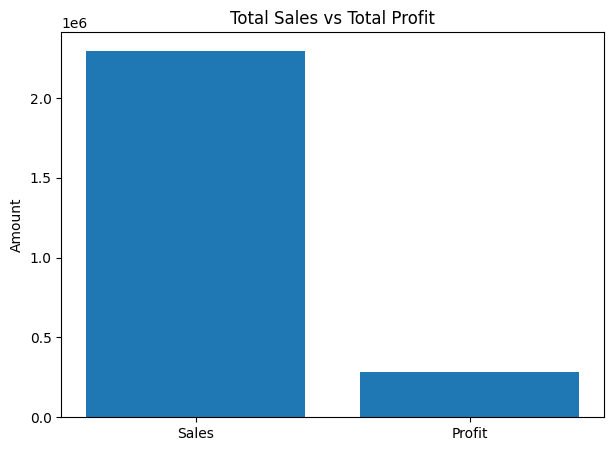

In [ ]:
metrics = ['Sales', 'Profit']
values = [total_sales, total_profit]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)
plt.title('Total Sales vs Total Profit')
plt.ylabel('Amount')
plt.show()

In [ ]:
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum()

category_analysis

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [ ]:
category_analysis = category_analysis.sort_values('Profit', ascending=False)

category_analysis

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728


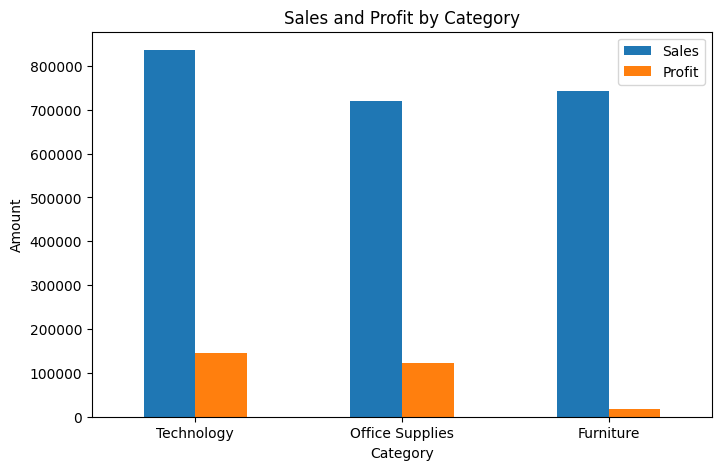

In [ ]:
category_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()

subcategory_profit = subcategory_profit.sort_values(ascending=False)

subcategory_profit

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [ ]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()

subcategory_profit = subcategory_profit.sort_values(ascending=False)

subcategory_profit

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [ ]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()

subcategory_profit = subcategory_profit.sort_values(ascending=False)

subcategory_profit

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [ ]:
region_profit = df.groupby('Region')['Profit'].sum()

region_profit = region_profit.sort_values(ascending=False)

region_profit

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


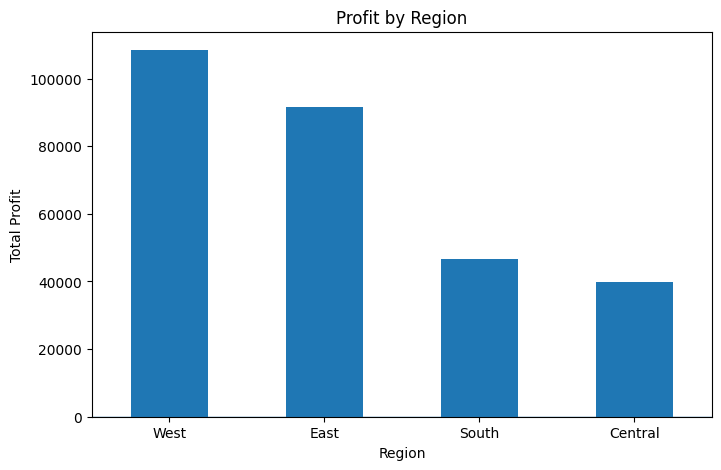

In [ ]:
plt.figure(figsize=(8,5))

region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.show()

In [ ]:
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum()

region_analysis = region_analysis.sort_values('Profit', ascending=False)

region_analysis

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [ ]:
print("Average Discount:", round(df['Discount'].mean() * 100, 2), "%")

Average Discount: 15.62 %


In [ ]:
discount_analysis = df.groupby('Discount')[['Sales', 'Profit']].sum()

discount_analysis

,Sales,Profit
Discount,,
0.00,1.087908e+06,320987.6032
0.10,5.436935e+04,9029.1770
0.15,2.755852e+04,1418.9915
0.20,7.645944e+05,90337.3060
0.30,1.032267e+05,-10369.2774
0.32,1.449346e+04,-2391.1377
0.40,1.164178e+05,-23057.0504
0.45,5.484974e+03,-2493.1111
0.50,5.891854e+04,-20506.4281


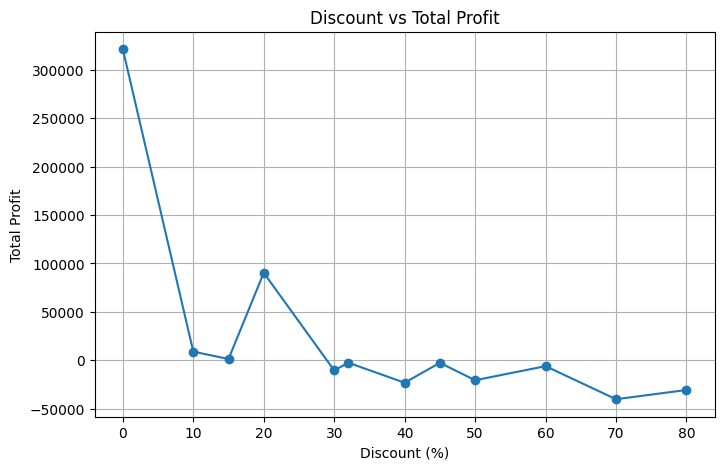

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    discount_analysis.index * 100,
    discount_analysis['Profit'],
    marker='o'
)

plt.title('Discount vs Total Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Total Profit')
plt.grid(True)
plt.show()

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [ ]:
year_analysis = df.groupby('Year')[['Sales', 'Profit']].sum()

year_analysis

,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


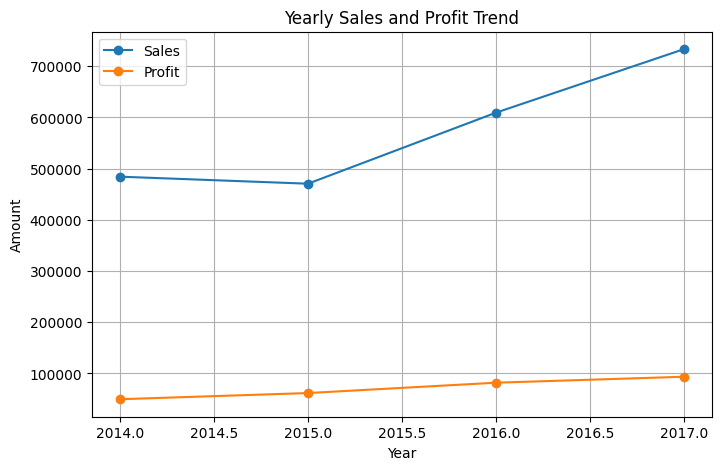

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(year_analysis.index, year_analysis['Sales'], marker='o', label='Sales')
plt.plot(year_analysis.index, year_analysis['Profit'], marker='o', label='Profit')

plt.title('Yearly Sales and Profit Trend')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

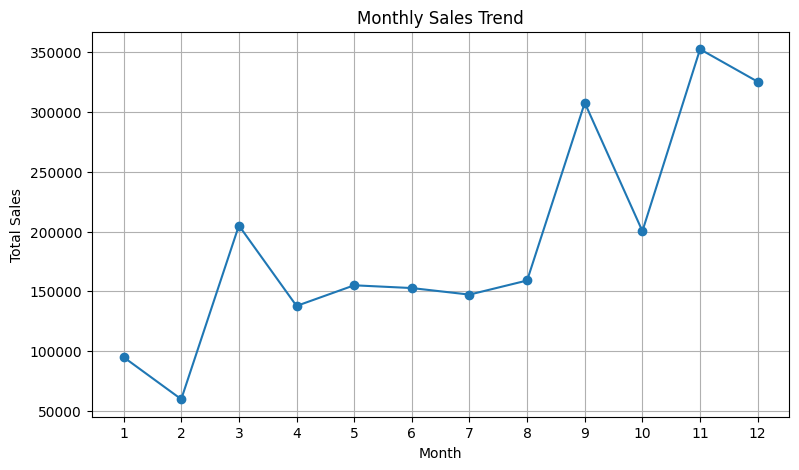

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(9,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

In [ ]:
top_products = df.groupby('Product Name')['Profit'].sum()

top_products = top_products.sort_values(ascending=False).head(10)

top_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


In [ ]:
bottom_products = df.groupby('Product Name')['Profit'].sum()

bottom_products = bottom_products.sort_values(ascending=True).head(10)

bottom_products

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


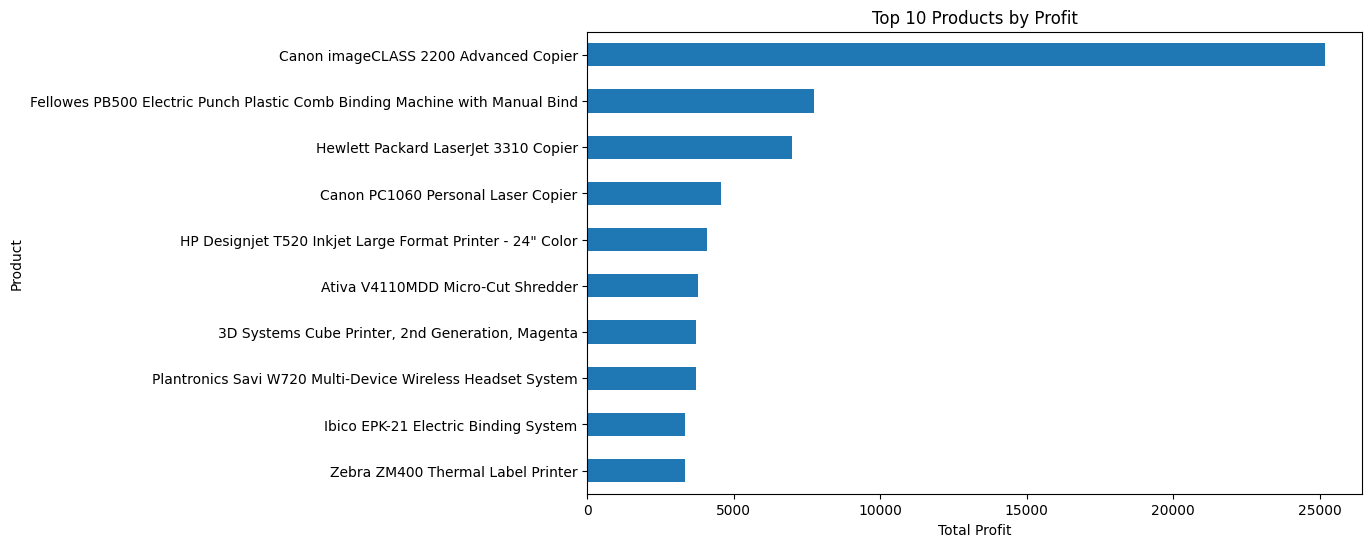

In [ ]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')
plt.show()

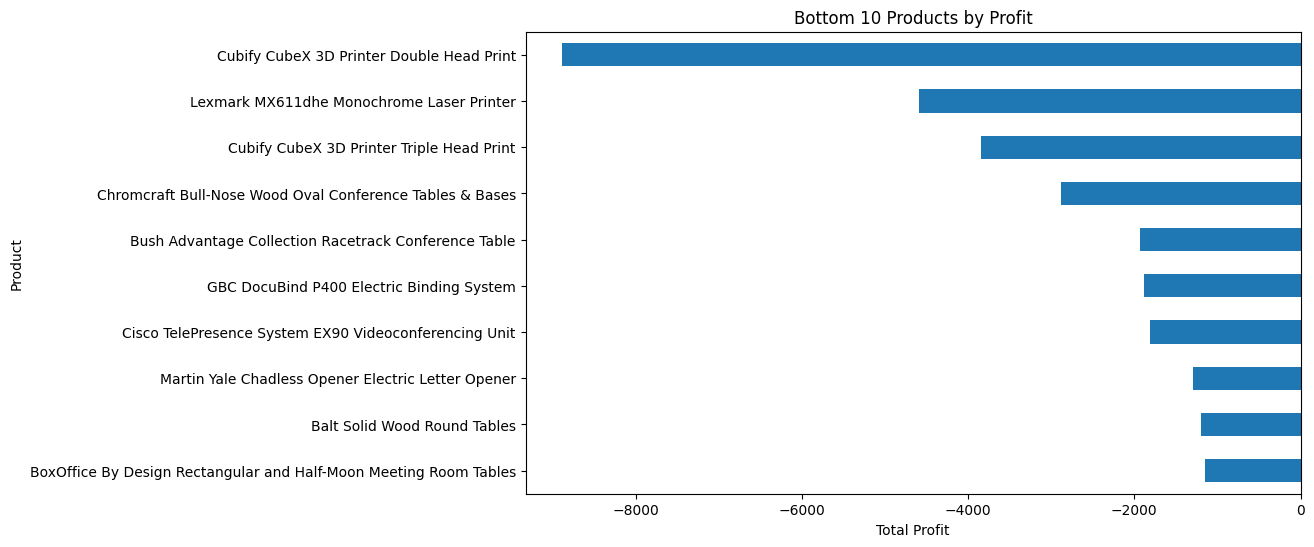

In [ ]:
plt.figure(figsize=(10,6))

bottom_products.sort_values(ascending=False).plot(kind='barh')

plt.title('Bottom 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect('retail_analysis.db')

df.to_sql('superstore', conn, if_exists='replace', index=False)

print("Database created successfully!")

Database created successfully!


In [ ]:
query = """
SELECT *
FROM superstore
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Year,Month
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00,2016,11
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00,2016,11
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00,2016,6
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00,2015,10
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25,2015,10


In [ ]:
query = """
SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore;
"""

pd.read_sql_query(query, conn)

,Total_Sales,Total_Profit
0,2297200.86,286397.02


In [ ]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Sales,Total_Profit
0,Technology,836154.03,145454.95
1,Office Supplies,719047.03,122490.80
2,Furniture,741999.80,18451.27


In [ ]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM superstore
GROUP BY Category
ORDER BY Profit_Margin DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Sales,Total_Profit,Profit_Margin
0,Technology,836154.03,145454.95,17.40
1,Office Supplies,719047.03,122490.80,17.04
2,Furniture,741999.80,18451.27,2.49


In [ ]:
query = """
SELECT
    [Sub-Category],
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM superstore
GROUP BY [Sub-Category]
ORDER BY Total_Profit ASC;
"""

pd.read_sql_query(query, conn)

,Sub-Category,Total_Sales,Total_Profit,Profit_Margin
0,Tables,206965.53,-17725.48,-8.56
1,Bookcases,114880.00,-3472.56,-3.02
2,Supplies,46673.54,-1189.10,-2.55
3,Fasteners,3024.28,949.52,31.40
4,Machines,189238.63,3384.76,1.79
5,Labels,12486.31,5546.25,44.42
6,Art,27118.79,6527.79,24.07
7,Envelopes,16476.40,6964.18,42.27
8,Furnishings,91705.16,13059.14,14.24
9,Appliances,107532.16,18138.01,16.87


In [ ]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql_query(query, conn)

,Region,Total_Sales,Total_Profit,Profit_Margin
0,West,725457.82,108418.45,14.94
1,East,678781.24,91522.78,13.48
2,South,391721.91,46749.43,11.93
3,Central,501239.89,39706.36,7.92


In [ ]:
query = """
SELECT
    ROUND(Discount * 100, 0) AS Discount_Percent,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY Discount
ORDER BY Discount;
"""

pd.read_sql_query(query, conn)

,Discount_Percent,Total_Sales,Total_Profit
0,0.0,1087908.47,320987.60
1,10.0,54369.35,9029.18
2,15.0,27558.52,1418.99
3,20.0,764594.37,90337.31
4,30.0,103226.65,-10369.28
5,32.0,14493.46,-2391.14
6,40.0,116417.78,-23057.05
7,45.0,5484.97,-2493.11
8,50.0,58918.54,-20506.43
9,60.0,6644.70,-5944.66


In [ ]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql_query(query, conn)

,Region,Total_Sales,Total_Profit,Profit_Margin
0,West,725457.82,108418.45,14.94
1,East,678781.24,91522.78,13.48
2,South,391721.91,46749.43,11.93
3,Central,501239.89,39706.36,7.92


In [ ]:
sql_code = """
-- Retail Business Analysis SQL Queries

-- 1. Total Sales and Profit
SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore;


-- 2. Category-wise Sales, Profit and Profit Margin
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM superstore
GROUP BY Category
ORDER BY Profit_Margin DESC;


-- 3. Sub-Category-wise Profitability
SELECT
    [Sub-Category],
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM superstore
GROUP BY [Sub-Category]
ORDER BY Total_Profit ASC;


-- 4. Region-wise Sales and Profit
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC;


-- 5. Discount vs Profit
SELECT
    ROUND(Discount * 100, 0) AS Discount_Percent,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY Discount
ORDER BY Discount;


-- 6. Top 10 Products by Profit
SELECT
    [Product Name],
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY [Product Name]
ORDER BY Total_Profit DESC
LIMIT 10;


-- 7. Bottom 10 Products by Profit
SELECT
    [Product Name],
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY [Product Name]
ORDER BY Total_Profit ASC
LIMIT 10;
"""

with open('/content/retail_analysis.sql', 'w') as f:
    f.write(sql_code)

print("retail_analysis.sql created successfully!")

retail_analysis.sql created successfully!


In [ ]:
from google.colab import files

files.download('/content/retail_analysis.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib import colors

pdf_path = "/content/Retail_Business_Analysis_Report.pdf"

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "Title",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=22,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "Heading",
    parent=styles["Heading2"],
    fontSize=15,
    spaceBefore=12,
    spaceAfter=8
)

body_style = ParagraphStyle(
    "Body",
    parent=styles["BodyText"],
    fontSize=10.5,
    leading=16,
    spaceAfter=8
)

story = []

story.append(Paragraph("RETAIL BUSINESS ANALYSIS", title_style))
story.append(Paragraph("Data Analysis Project Report", styles["Heading2"]))
story.append(Spacer(1, 15))

story.append(Paragraph("1. Introduction", heading_style))
story.append(Paragraph(
    "This project focuses on analyzing retail business data to understand "
    "sales performance, profitability, product performance, regional "
    "performance, discount impact, and seasonal sales patterns.",
    body_style
))

story.append(Paragraph("2. Objectives", heading_style))
objectives = [
    "Analyze overall sales and profit performance.",
    "Identify profitable and less profitable product categories and sub-categories.",
    "Compare sales and profit across different regions.",
    "Analyze the relationship between discounts and profit.",
    "Identify top-performing products.",
    "Analyze monthly sales trends and seasonality.",
    "Provide recommendations to improve business profitability."
]

for item in objectives:
    story.append(Paragraph("• " + item, body_style))

story.append(Paragraph("3. Dataset", heading_style))
story.append(Paragraph(
    "The project uses the Superstore dataset containing 9,994 records and "
    "21 columns. The dataset contains information about orders, customers, "
    "products, sales, quantity, discounts, regions, and profit.",
    body_style
))

story.append(Paragraph("4. Tools and Technologies", heading_style))
tools = [
    "Python – Data cleaning and Exploratory Data Analysis",
    "Pandas and NumPy – Data manipulation",
    "Matplotlib and Seaborn – Data visualization",
    "SQL – Business data analysis and querying",
    "Tableau Public – Interactive dashboard creation"
]

for item in tools:
    story.append(Paragraph("• " + item, body_style))

story.append(Paragraph("5. Key Analysis and Findings", heading_style))

findings = [
    "<b>Total Sales:</b> 2,297,201",
    "<b>Total Profit:</b> 286,397",
    "<b>Best Category:</b> Technology, with approximately 836,154 in sales and 145,455 in profit.",
    "<b>Best Region:</b> West, with approximately 725,458 in sales and 108,418 in profit.",
    "<b>Lowest Profit Margin Category:</b> Furniture, with a profit margin of approximately 2.49%.",
    "<b>Discount Analysis:</b> Higher discount levels, particularly 30% and above, are associated with negative profit at several discount levels.",
    "<b>Seasonality:</b> November has the highest overall monthly sales, while February has the lowest."
]

for item in findings:
    story.append(Paragraph("• " + item, body_style))

story.append(Paragraph("6. Business Recommendations", heading_style))
recommendations = [
    "Focus on high-performing Technology products and profitable product lines.",
    "Review Furniture pricing and discount strategies because of its low profit margin.",
    "Pay attention to the Central region because it has the lowest profit margin.",
    "Avoid excessive discounting where it results in negative profitability.",
    "Plan inventory and marketing activities around stronger sales months.",
    "Monitor loss-making products and consider pricing or product strategy changes."
]

for item in recommendations:
    story.append(Paragraph("• " + item, body_style))

story.append(Paragraph("7. Conclusion", heading_style))
story.append(Paragraph(
    "The analysis provides useful insights into the sales and profitability "
    "of the retail business. Technology is the strongest category, while the "
    "West region performs best in terms of sales and profit. The analysis also "
    "shows that excessive discounts can be associated with lower profitability. "
    "The Tableau dashboard presents these findings visually and supports "
    "data-driven business decision-making.",
    body_style
))

doc.build(story)

print("PDF report created successfully!")

PDF report created successfully!


In [2]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.4 MB/s eta 0:00:00


In [4]:
from google.colab import files
files.download('/content/Retail_Business_Analysis_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>